In [1]:
# === Imports & device ===

import os, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
from collections import Counter

from PIL import Image
import cv2

# PyTorch + timm
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from imblearn.over_sampling import SMOTE
import timm

# sklearn metrics
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, precision_score, recall_score, f1_score,
    accuracy_score, precision_recall_curve, average_precision_score
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

print ('modules loaded')

Device: cpu
modules loaded


In [2]:
# === Defining the dataset paths ===

train_dataset_path = r"C:\Users\HP\Desktop\adam\adamtrain\1"
validation_dataset_path = r"C:\Users\HP\Desktop\adam\adamval\1"
test_dataset_path = r"C:\Users\HP\Desktop\adam\adamtest\1"

train_dir = r"C:\Users\HP\Desktop\adam\adamtrain"
validation_dir = r"C:\Users\HP\Desktop\adam\adamval"
test_dir = r"C:\Users\HP\Desktop\adam\adamtest"

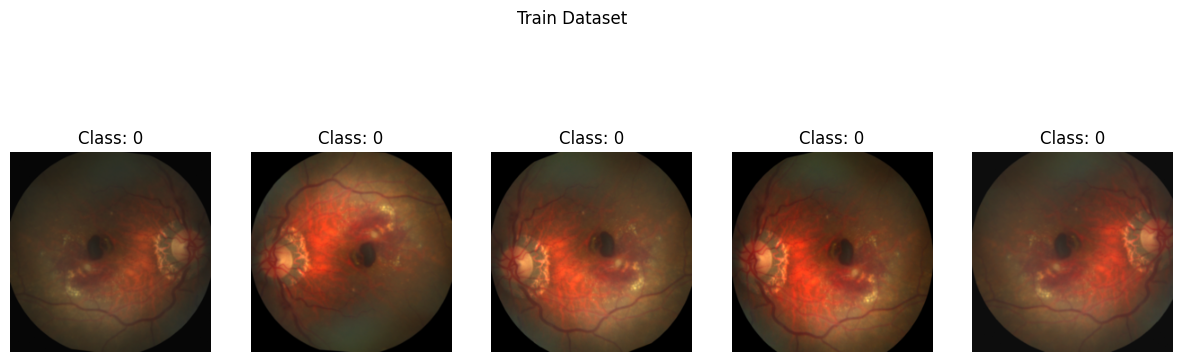

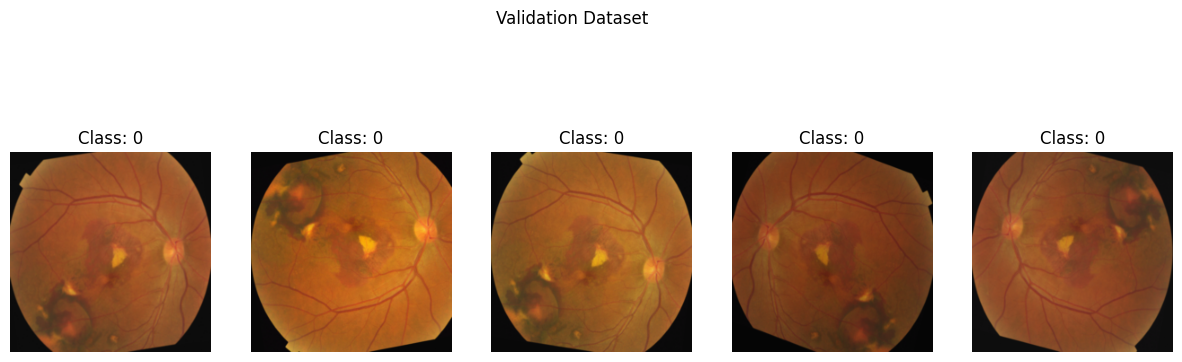

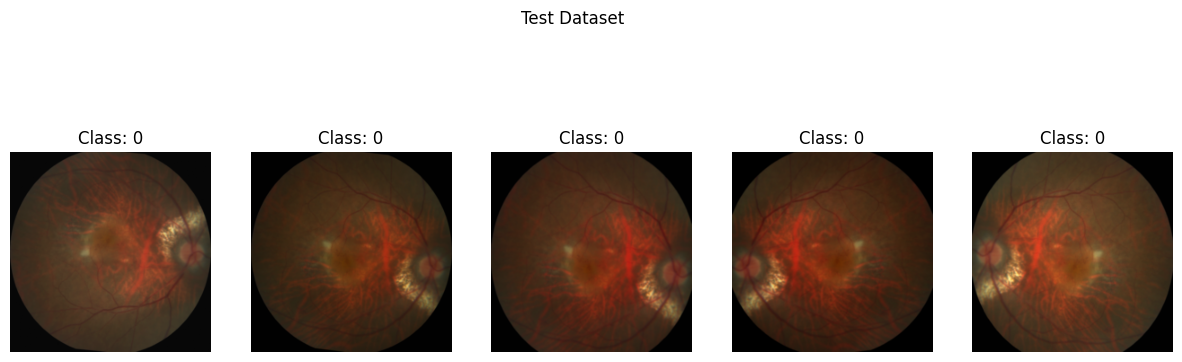

In [3]:
# === Function to show images ===

# Just resizing + tensor conversion for visualization
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Load datasets
train_dataset = datasets.ImageFolder(train_dir, transform=transform)
val_dataset = datasets.ImageFolder(validation_dir, transform=transform)
test_dataset = datasets.ImageFolder(test_dir, transform=transform)

def show_images(dataset, num_images=5, title="Dataset Sample"):
    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        img, label = dataset[i]
        img = img.permute(1, 2, 0)  # convert CHW → HWC for plotting
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {label}")
        axes[i].axis("off")
    plt.suptitle(title)
    plt.show()

# Show few samples
show_images(train_dataset, num_images=5, title="Train Dataset")
show_images(val_dataset, num_images=5, title="Validation Dataset")
show_images(test_dataset, num_images=5, title="Test Dataset")

## SMOTE + Oversampling Pipeline

In [4]:
# ---------------------------
# Image Transforms
# ---------------------------

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

In [5]:
# ---------------------------
# Datasets
# ---------------------------

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset = datasets.ImageFolder(validation_dir, transform=val_test_transform)
test_dataset = datasets.ImageFolder(test_dir, transform=val_test_transform)

In [6]:
# ---------------------------
# Step 1: Extract features for SMOTE
# ---------------------------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [7]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Image transformations (adjust size depending on your images, here 224x224)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load dataset (replace with your ADAM paths)
train_dir = r"C:\Users\HP\Desktop\adam\adamtrain"
train_dataset = datasets.ImageFolder(root=train_dir, transform=transform)

# Create DataLoader
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

print("Classes:", train_dataset.classes)
print("Number of samples:", len(train_dataset))

Classes: ['0', '1']
Number of samples: 4445


In [8]:
# Pretrained ResNet as feature extractor

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


# Define ResNet20 (CIFAR style, small + efficient)
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_planes, planes, stride=1):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_planes != self.expansion * planes:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, self.expansion * planes, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * planes)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        out = F.relu(out)
        return out

class ResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=2):
        super(ResNet, self).__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.5)  # ✅ added dropout
        self.linear = nn.Linear(64, num_classes)

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for stride in strides:
            layers.append(block(self.in_planes, planes, stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.dropout(out)   
        out = self.linear(out)
        return out

def ResNet20(num_classes=2):
    return ResNet(BasicBlock, [3, 3, 3], num_classes=num_classes)

# Usage as Feature Extractor
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ResNet20(num_classes=2).to(device)
model.eval()

# Example: using your train_loader
features, labels = [], []
with torch.no_grad():
    for imgs, lbls in train_loader:
        imgs = imgs.to(device)
        feats = model(imgs)  # directly outputs 2-class logits
        features.append(feats.cpu().numpy())
        labels.append(lbls.numpy())

features = np.vstack(features)
labels = np.hstack(labels)

print("Features shape:", features.shape)
print("Original class distribution:", np.bincount(labels))

Features shape: (4445, 2)
Original class distribution: [1335 3110]


#### This code above builds a mini-ResNet20, uses it as a feature extractor, and collects 2-class logits for each image.

In [9]:
# ---------------------------
# Step 2: Apply SMOTE
# ---------------------------

smote = SMOTE(sampling_strategy='auto', random_state=42)
X_res, y_res = smote.fit_resample(features, labels)

print("Balanced class distribution:", np.bincount(y_res))

Balanced class distribution: [3110 3110]


In [10]:
# ---------------------------
# Step 3: Oversampling Sampler for Training
# ---------------------------
# Compute class weights (for oversampling)

class_counts = np.bincount(labels)  # original imbalance
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[label] for label in train_dataset.targets]

sampler = WeightedRandomSampler(weights=sample_weights,
                                num_samples=len(sample_weights),
                                replacement=True)

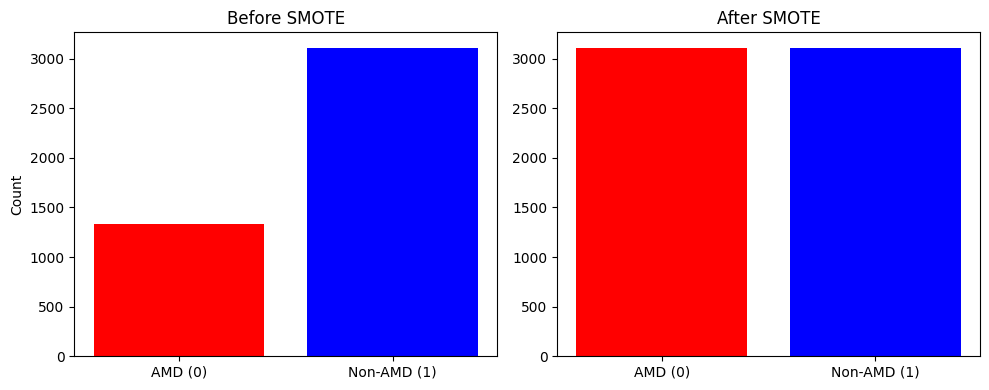

In [11]:
# ---------------------------
# Class Distribution (Before & After SMOTE)
# ---------------------------

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# Before SMOTE
ax[0].bar([0, 1], np.bincount(labels), color=['red', 'blue'])
ax[0].set_title("Before SMOTE")
ax[0].set_xticks([0, 1])
ax[0].set_xticklabels(["AMD (0)", "Non-AMD (1)"])
ax[0].set_ylabel("Count")

# After SMOTE
ax[1].bar([0, 1], np.bincount(y_res), color=['red', 'blue'])
ax[1].set_title("After SMOTE")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["AMD (0)", "Non-AMD (1)"])

plt.tight_layout()
plt.show()

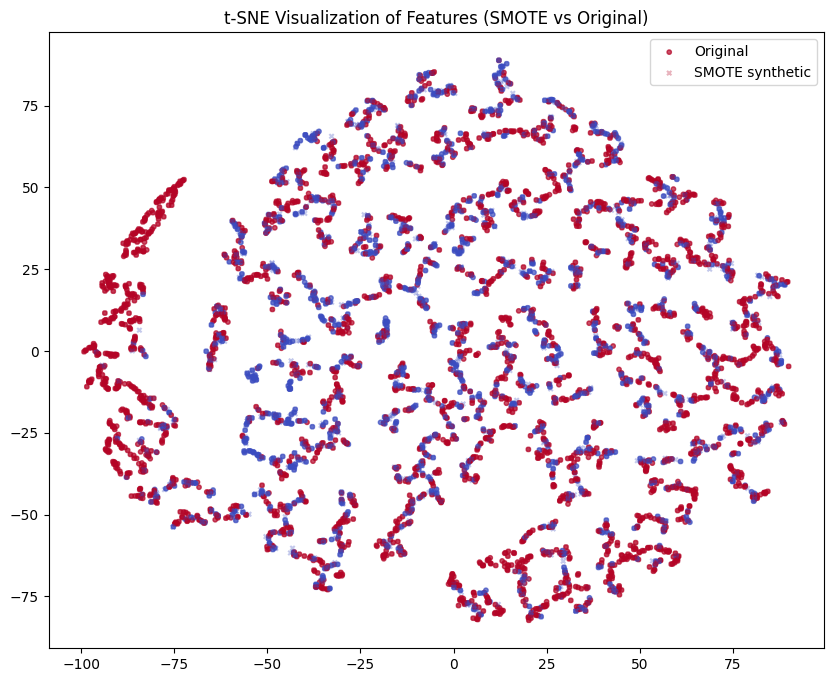

In [12]:
# ---------------------------
# t-SNE Visualization (Feature Space with SMOTE)
# ---------------------------

from sklearn.manifold import TSNE

# --- Subsample for readability ---
max_points = 5000  # adjust depending on dataset size
idx = np.random.choice(len(features), size=min(max_points, len(features)), replace=False)
features_sample = features[idx]
labels_sample = labels[idx]

idx_res = np.random.choice(len(X_res), size=min(max_points, len(X_res)), replace=False)
X_res_sample = X_res[idx_res]
y_res_sample = y_res[idx_res]

# --- Run t-SNE on combined sample ---
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000, learning_rate="auto")
X_embedded = tsne.fit_transform(np.vstack([features_sample, X_res_sample]))

# --- Separate original vs synthetic ---
n_original = len(features_sample)
original_labels = labels_sample
synthetic_labels = y_res_sample

# --- Plot ---
plt.figure(figsize=(10, 8))
plt.scatter(X_embedded[:n_original, 0], X_embedded[:n_original, 1],
            c=original_labels, cmap="coolwarm", alpha=0.7, s=10, label="Original")
plt.scatter(X_embedded[n_original:, 0], X_embedded[n_original:, 1],
            c=synthetic_labels, cmap="coolwarm", alpha=0.3, s=10, marker="x", label="SMOTE synthetic")

plt.legend()
plt.title("t-SNE Visualization of Features (SMOTE vs Original)")
plt.show()

#### What it shows:

* Each point represents a sample (reduced to 2D using t-SNE).

* Colors:
        🔴 Red = Original samples, 
        🔵 Blue = SMOTE synthetic samples

* Distribution:
The SMOTE points (blue) are intermixed with red points, meaning the synthetic data is generated close to the original data.
There aren’t many “blue-only clusters” far away, which would suggest unrealistic or noisy synthetic samples.

* It visually confirms that your synthetic AMD samples look statistically similar to real AMD samples in feature space. This gives more confidence that the model trained on this augmented dataset will generalize better and not just learn artifacts.

* This graph tells you SMOTE has generated synthetic data that blends well with the original, improving balance without creating strange outliers.

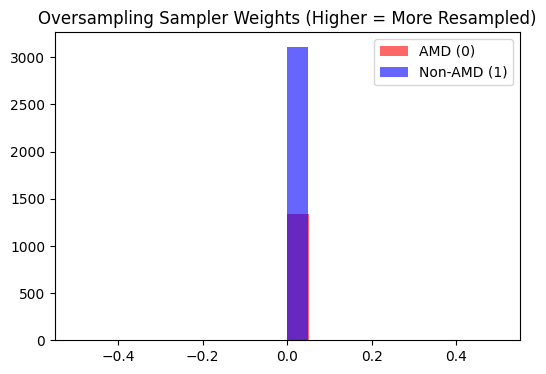

In [13]:
# ---------------------------
# Oversampling Effect (Sampler Weights)
# ---------------------------

sample_weights_np = np.array(sample_weights)
plt.figure(figsize=(6,4))
plt.hist([w for i, w in enumerate(sample_weights_np) if train_dataset.targets[i]==0],
         bins=20, alpha=0.6, color='red', label="AMD (0)")
plt.hist([w for i, w in enumerate(sample_weights_np) if train_dataset.targets[i]==1],
         bins=20, alpha=0.6, color='blue', label="Non-AMD (1)")
plt.legend()
plt.title("Oversampling Sampler Weights (Higher = More Resampled)")
plt.show()

#### This graph is related to class imbalance handling using a weighted sampler.

* The red bar (AMD) is shorter, meaning AMD samples are fewer in your dataset.
* The sampler compensates by assigning higher weights to AMD images, so they get oversampled more frequently during training.
* The blue bar (Non-AMD) is taller because it has more raw images, but its effective sampling weight is lower compared to AMD.
* This ensures that when the DataLoader feeds data into your model, AMD and Non-AMD samples are seen more equally often, preventing the model from being biased toward the majority class.
* This graph tells you how the weighted sampler is balancing your dataset. AMD samples are being oversampled more to match the number of Non-AMD samples, helping fix class imbalance during training.

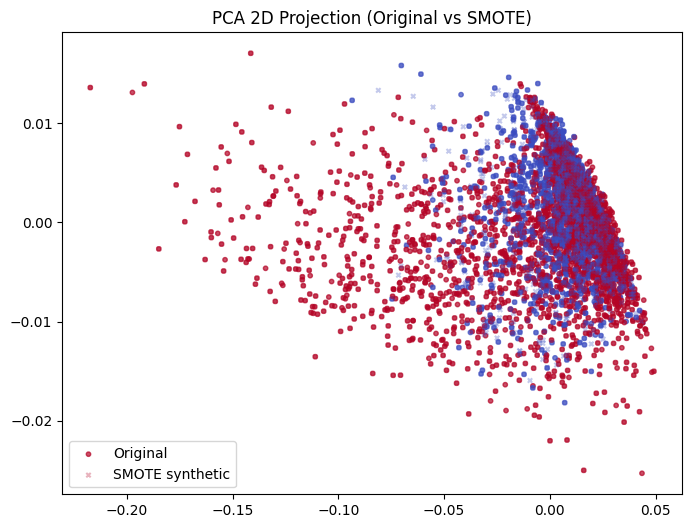

In [15]:
# ---------------------------
# PCA 2D Visualization (Original vs SMOTE)
# ---------------------------

from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(np.vstack([features_sample, X_res_sample]))

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:n_original,0], X_pca[:n_original,1], 
            c=original_labels, cmap="coolwarm", s=10, alpha=0.7, label="Original")
plt.scatter(X_pca[n_original:,0], X_pca[n_original:,1], 
            c=synthetic_labels, cmap="coolwarm", s=10, alpha=0.3, marker="x", label="SMOTE synthetic")
plt.title("PCA 2D Projection (Original vs SMOTE)")
plt.legend()
plt.show()

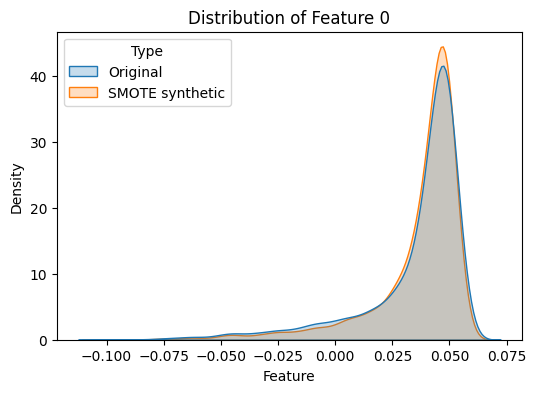

In [16]:
# ---------------------------
# Feature Distribution Comparison (KDE / Violin)
# ---------------------------

import seaborn as sns
import pandas as pd

# Pick a feature index to visualize
feat_idx = 0  # try 0, 1, 2...
df = pd.DataFrame({
    "Feature": np.hstack([features_sample[:,feat_idx], X_res_sample[:,feat_idx]]),
    "Type": ["Original"]*len(features_sample) + ["SMOTE synthetic"]*len(X_res_sample)
})

plt.figure(figsize=(6,4))
sns.kdeplot(data=df, x="Feature", hue="Type", fill=True, common_norm=False)
plt.title(f"Distribution of Feature {feat_idx}")
plt.show()

## End-to-end Swin Transformer training pipeline

In [5]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [9]:
# ============================
# 1. CONFIG
# ============================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 32
EPOCHS = 60
LR = 1e-4
PATIENCE = 12   # early stopping patience

train_dir = r"C:\Users\HP\Desktop\adam\adamtrain"
validation_dir = r"C:\Users\HP\Desktop\adam\adamval"
test_dir = r"C:\Users\HP\Desktop\adam\adamtest"

In [10]:
# ============================
# 2. DATA AUGMENTATION
# ============================

import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.5),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [11]:
# ============================
# 3. DATASETS & SAMPLER
# ============================

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(validation_dir, transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_transform)

class_counts = np.bincount(train_dataset.targets)
class_weights = 1. / class_counts
sample_weights = [class_weights[t] for t in train_dataset.targets]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
# ============================
# 4. MODEL (Swin + Dropout)
# ============================

model = timm.create_model("swin_small_patch4_window7_224", pretrained=True, num_classes=2, drop_rate=0.3)
model = model.to(DEVICE)

In [28]:
# ============================
# 5. LOSS + OPTIMIZER + SCHEDULER
# ============================

num_amd, num_non_amd = class_counts[0], class_counts[1]
total = num_amd + num_non_amd
w0 = total / num_amd
w1 = total / num_non_amd
class_weights = torch.tensor([w0, w1], dtype=torch.float).to(DEVICE)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, verbose=True)

In [30]:
import copy
best_model_wts = copy.deepcopy(model.state_dict())

 Epoch 1: New best model (Val Acc: 0.6475)
Epoch [1/60] Train Loss: 0.2799, Train Acc: 0.8407, Val Loss: 1.3134, Val Acc: 0.6475
 Epoch 2: New best model (Val Acc: 0.8391)
Epoch [2/60] Train Loss: 0.1113, Train Acc: 0.9465, Val Loss: 1.0862, Val Acc: 0.8391
 Epoch 3: New best model (Val Acc: 0.8821)
Epoch [3/60] Train Loss: 0.0838, Train Acc: 0.9604, Val Loss: 0.6596, Val Acc: 0.8821
Epoch [4/60] Train Loss: 0.0700, Train Acc: 0.9687, Val Loss: 0.9232, Val Acc: 0.8056
 Epoch 5: New best model (Val Acc: 0.8868)
Epoch [5/60] Train Loss: 0.0607, Train Acc: 0.9739, Val Loss: 0.6691, Val Acc: 0.8868
Epoch [6/60] Train Loss: 0.0458, Train Acc: 0.9802, Val Loss: 1.0944, Val Acc: 0.8432
Epoch [7/60] Train Loss: 0.0412, Train Acc: 0.9811, Val Loss: 1.4788, Val Acc: 0.8364
Epoch [8/60] Train Loss: 0.0504, Train Acc: 0.9766, Val Loss: 0.9532, Val Acc: 0.8369
Epoch [9/60] Train Loss: 0.0353, Train Acc: 0.9831, Val Loss: 1.2126, Val Acc: 0.8358
Epoch [10/60] Train Loss: 0.0210, Train Acc: 0.9901, V

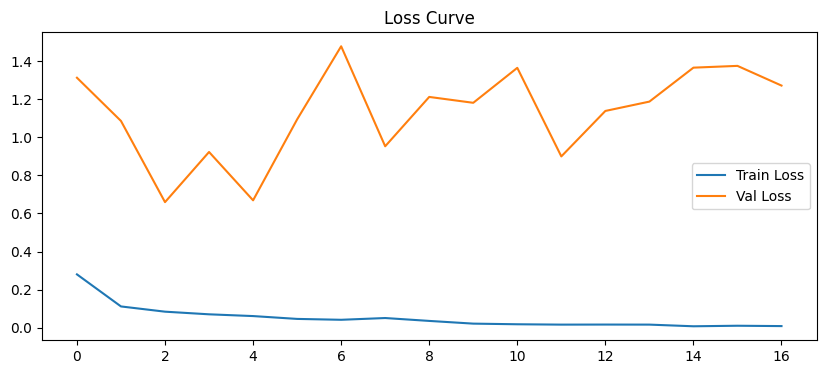

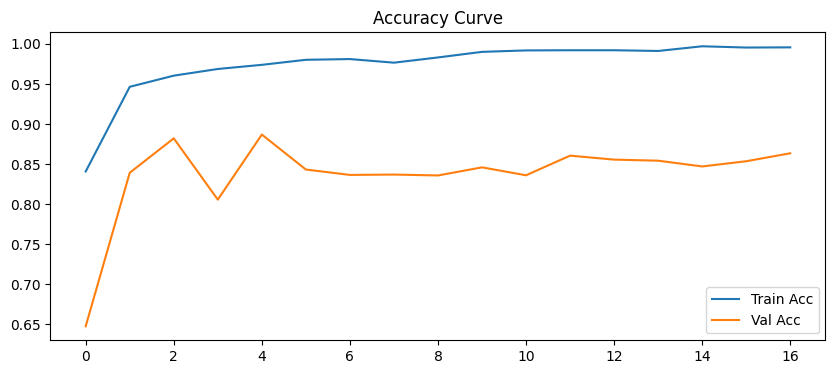

In [31]:
# ============================
# 6. TRAINING LOOP + EARLY STOP
# ============================

train_loss_hist, val_loss_hist = [], []
train_acc_hist, val_acc_hist = [], []

best_val_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())
early_stop_counter = 0

for epoch in range(EPOCHS):
    # TRAIN
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # VALIDATION
    model.eval()
    val_running_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
            val_total += labels.size(0)

    val_loss = val_running_loss / val_total
    val_acc = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    scheduler.step(val_acc)

    # SAVE BEST
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        early_stop_counter = 0
        print(f" Epoch {epoch+1}: New best model (Val Acc: {best_val_acc:.4f})")
    else:
        early_stop_counter += 1
        if early_stop_counter >= PATIENCE:
            print(" Early stopping triggered!")
            break

    print(f"Epoch [{epoch+1}/{EPOCHS}] "
          f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# ============================
# 7. SAVE BEST MODEL
# ============================
model.load_state_dict(best_model_wts)
torch.save(model.state_dict(), "best_amd_model.pth")
print(f" Training complete. Best model saved with Val Acc: {best_val_acc:.4f}")

# ============================
# 8. VISUALIZATION
# ============================
plt.figure(figsize=(10,4))
plt.plot(train_loss_hist, label="Train Loss")
plt.plot(val_loss_hist, label="Val Loss")
plt.legend(); plt.title("Loss Curve"); plt.show()

plt.figure(figsize=(10,4))
plt.plot(train_acc_hist, label="Train Acc")
plt.plot(val_acc_hist, label="Val Acc")
plt.legend(); plt.title("Accuracy Curve"); plt.show()

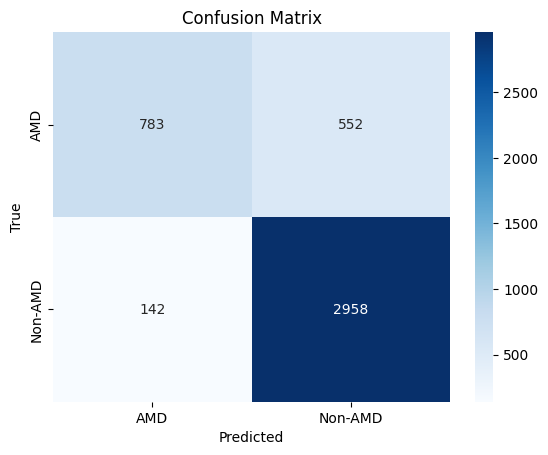

 Test Accuracy: 0.8435

Classification Report:
               precision    recall  f1-score   support

         AMD       0.85      0.59      0.69      1335
     Non-AMD       0.84      0.95      0.90      3100

    accuracy                           0.84      4435
   macro avg       0.84      0.77      0.79      4435
weighted avg       0.84      0.84      0.83      4435



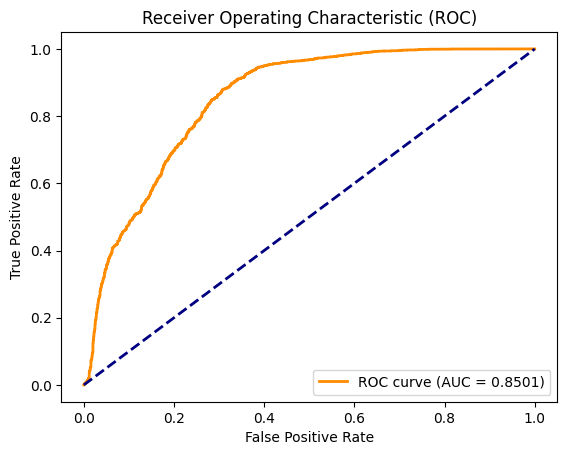

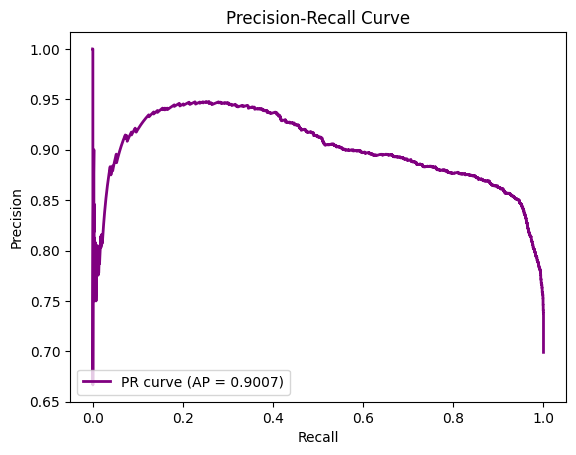

In [32]:
# ============================
# 9. TEST EVALUATION
# ============================

#  Make Predictions
model.eval()
y_true, y_pred, y_prob = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # probabilities

        preds = torch.argmax(probs, dim=1)     # predicted class

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_prob.extend(probs.cpu().numpy())     # store full [P(AMD), P(Non-AMD)]

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# II. Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AMD","Non-AMD"], yticklabels=["AMD","Non-AMD"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# III. Accuracy & Report
acc = accuracy_score(y_true, y_pred)
print(f" Test Accuracy: {acc:.4f}\n")
print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["AMD","Non-AMD"]))

# IV. ROC Curve & AUC
y_prob_class1 = y_prob[:, 1]  # probability of class "Non-AMD"

fpr, tpr, _ = roc_curve(y_true, y_prob_class1, pos_label=1)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")
plt.show()

# V. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_prob_class1, pos_label=1)
ap = average_precision_score(y_true, y_prob_class1, pos_label=1)

plt.figure()
plt.plot(recall, precision, color="purple", lw=2, label=f"PR curve (AP = {ap:.4f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import copy

# ============================
# 1. Reload Best Model
# ============================
checkpoint = torch.load("best_amd_model.pth", map_location=device)
model.load_state_dict(checkpoint)
model.to(device)

# ============================
# 2. Add Regularization
# ============================

# Add dropout in classifier head
if hasattr(model.head, "drop"):
    model.head.drop = nn.Dropout(p=0.4)  # you can try 0.3–0.5
else:
    # If no dropout layer, wrap it manually
    in_features = model.head.in_features
    model.head = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 2)
    )

# Label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# ============================
# 3. Fine-tuning Setup
# ============================
# Use smaller LR for fine-tuning
optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-4)

# Reduce LR on plateau
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                 factor=0.5, patience=2,
                                                 verbose=True)

# ============================
# 4. Fine-tune for 5–10 Epochs
# ============================
EPOCHS = 10
best_val_acc = 0.8868   # already known best
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(EPOCHS):
    print(f"\nFine-tune Epoch {epoch+1}/{EPOCHS}")

    # ---- Training ----
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validation ----
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    scheduler.step(val_loss)

    print(f" Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, "
          f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ---- Save best ----
    if val_acc > best_val_acc:
        print(f"New best model! Val Acc improved from {best_val_acc:.4f} → {val_acc:.4f}")
        best_val_acc = val_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(best_model_wts, "best_amd_model_finetuned.pth")

# Load best weights back
model.load_state_dict(best_model_wts)


Fine-tune Epoch 1/10
 Train Loss: 0.2601, Train Acc: 0.9840, Val Loss: 0.5212, Val Acc: 0.8551

Fine-tune Epoch 2/10
 Train Loss: 0.2212, Train Acc: 0.9912, Val Loss: 0.5147, Val Acc: 0.8558

Fine-tune Epoch 3/10
 Train Loss: 0.2147, Train Acc: 0.9930, Val Loss: 0.4970, Val Acc: 0.8601

Fine-tune Epoch 4/10
 Train Loss: 0.2156, Train Acc: 0.9912, Val Loss: 0.4948, Val Acc: 0.8686

Fine-tune Epoch 5/10
 Train Loss: 0.2158, Train Acc: 0.9924, Val Loss: 0.5064, Val Acc: 0.8605

Fine-tune Epoch 6/10
 Train Loss: 0.2097, Train Acc: 0.9951, Val Loss: 0.5214, Val Acc: 0.8587

Fine-tune Epoch 7/10
 Train Loss: 0.2127, Train Acc: 0.9926, Val Loss: 0.5042, Val Acc: 0.8630

Fine-tune Epoch 8/10
 Train Loss: 0.2076, Train Acc: 0.9953, Val Loss: 0.5009, Val Acc: 0.8646

Fine-tune Epoch 9/10
 Train Loss: 0.2094, Train Acc: 0.9946, Val Loss: 0.5129, Val Acc: 0.8598

Fine-tune Epoch 10/10
 Train Loss: 0.2067, Train Acc: 0.9962, Val Loss: 0.5147, Val Acc: 0.8632


<All keys matched successfully>

#### Since my best model already reached Val Acc = 0.8868, the safest approach is to reload that checkpoint and continue training with:

* Lower learning rate (fine-tuning mode).
* Regularization (Dropout, Label Smoothing, stronger Augmentations).
* Shorter schedule (5–10 epochs) to see if performance improves.

##### What I have done : 

* Dropout (0.4) in classifier head → combats overfitting.
* Label smoothing (0.1) → prevents overconfident predictions.
* LR = 1e-5 (fine-tuning) → much lower than before.
* ReduceLROnPlateau → auto-tunes LR if val loss stalls.
* Train for 5–10 extra epochs only → to refine, not overfit.
* Save as "best_amd_model_finetuned.pth".

 Final Test Accuracy: 0.8435


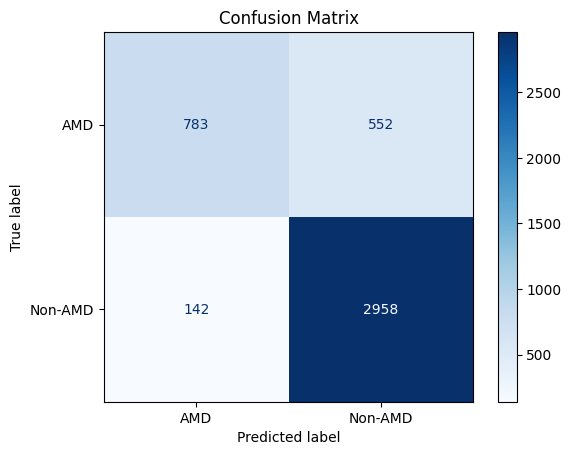

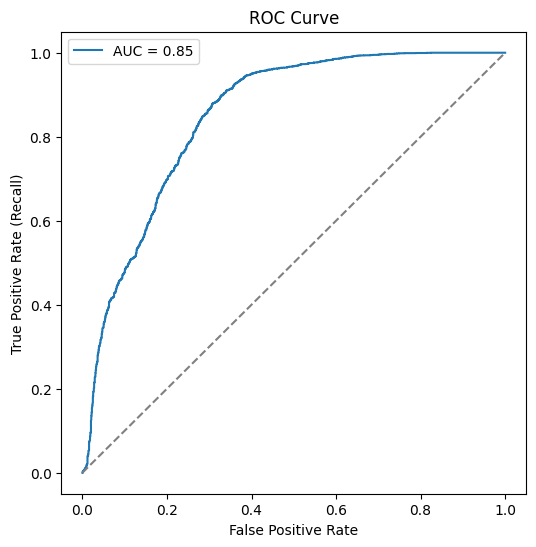

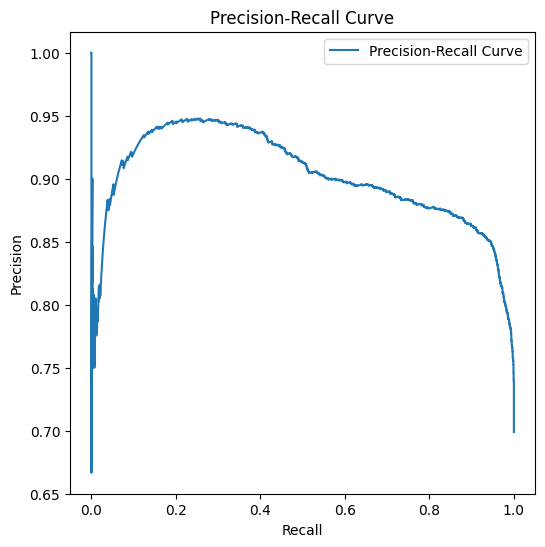


📄 Classification Report:
              precision    recall  f1-score   support

         AMD       0.85      0.59      0.69      1335
     Non-AMD       0.84      0.95      0.90      3100

    accuracy                           0.84      4435
   macro avg       0.84      0.77      0.79      4435
weighted avg       0.84      0.84      0.83      4435



In [19]:
# ============================
# 1. Use the best fine-tuned model
# ============================

checkpoint = torch.load("C:\\Users\\HP\\Desktop\\best_amd_model.pth", map_location=device)
model.load_state_dict(checkpoint)
model.to(device)
model.eval()

# ============================
# 2. Collect predictions on test set
# ============================
y_true, y_pred, y_probs = [], [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of class 1 (Non-AMD)

        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())
        y_probs.extend(probs.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_probs = np.array(y_probs)

# ============================
# 3. Test Accuracy
# ============================
acc = (y_true == y_pred).mean()
print(f" Final Test Accuracy: {acc:.4f}")

# ============================
# 4. Confusion Matrix
# ============================
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["AMD", "Non-AMD"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

# ============================
# 5. ROC Curve
# ============================
fpr, tpr, _ = roc_curve(y_true, y_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ============================
# 6. Precision-Recall Curve
# ============================
prec, rec, _ = precision_recall_curve(y_true, y_probs)

plt.figure(figsize=(6, 6))
plt.plot(rec, prec, label="Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# ============================
# 7. Classification Report
# ============================
print("\n📄 Classification Report:")
print(classification_report(y_true, y_pred, target_names=["AMD", "Non-AMD"]))

## Prediction

In [20]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# =========================
# I. Define Transform (must match training)
# =========================

transform = transforms.Compose([
    transforms.Resize((224, 224)),   # must match model input size
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet normalization
                         std=[0.229, 0.224, 0.225])
])

# =========================
# II. Class Labels
# =========================

class_names = ["AMD", "Non-AMD"]

# =========================
# III. Prediction Function
# =========================

def predict_image(image_path, model, device):
    model.eval()

    # Load and preprocess image
    image = Image.open(image_path).convert("RGB")
    img_tensor = transform(image).unsqueeze(0).to(device)  # Add batch dimension

    # Forward pass
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1).cpu().numpy()[0]
        pred_class = probs.argmax()

    # Print results
    print("="*50)
    print(f"Image Path : {image_path}")
    print(f"Image Size : {image.size}")
    print(f"Predicted  : {class_names[pred_class]}")
    print(f"Probabilities -> AMD: {probs[0]:.4f}, Non-AMD: {probs[1]:.4f}")
    print("="*50)

    # Show image with prediction
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[pred_class]}\nAMD={probs[0]:.2f}, Non-AMD={probs[1]:.2f}")
    plt.show()

    return class_names[pred_class], probs

Image Path : C:\Users\HP\Desktop\AMDdataset\test\0\1ffa953e-8d87-11e8-9daf-6045cb817f5b..JPG
Image Size : (3046, 2572)
Predicted  : AMD
Probabilities -> AMD: 0.9984, Non-AMD: 0.0016


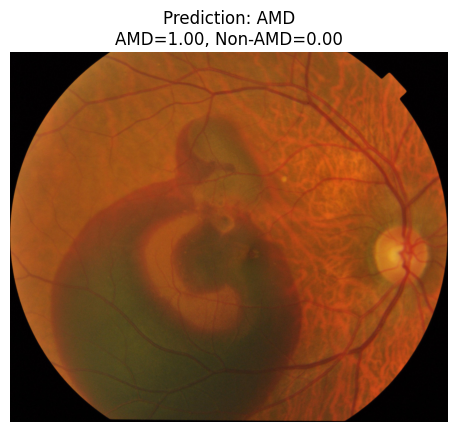

('AMD', array([0.99837756, 0.00162241], dtype=float32))

In [21]:
img_path = r"C:\Users\HP\Desktop\AMDdataset\test\0\1ffa953e-8d87-11e8-9daf-6045cb817f5b..JPG"
predict_image(img_path, model, device)

Image Path : C:\Users\HP\Desktop\AMDdataset\test\1\1017_right.jpg
Image Size : (2048, 2048)
Predicted  : Non-AMD
Probabilities -> AMD: 0.0002, Non-AMD: 0.9998


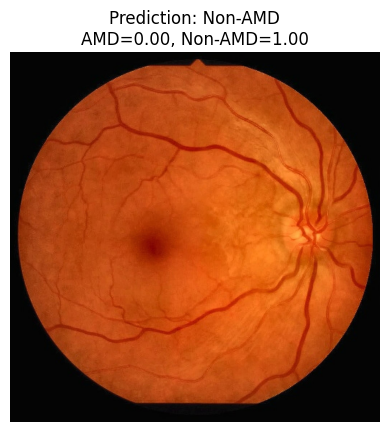

('Non-AMD', array([2.2493994e-04, 9.9977511e-01], dtype=float32))

In [22]:
img_path = r"C:\Users\HP\Desktop\AMDdataset\test\1\1017_right.jpg"
predict_image(img_path, model, device)